In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Markdown

mpl.rcParams['font.size'] = 16

In [2]:
def read_file(filename):
    with open(filename) as f:
        data = []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            data.append(float(temp[4]))

    return data

def read_file_with_smiles(filename):
    with open(filename) as f:
        data = []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            data.append(float(temp[5]))

    return data

def plot_hist(data, output):
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(111)
    ax1.hist(data, bins=range(0, int(np.max(data))))
    ax1.set_xlabel('time [ms]')
    #ax1.set_xlim(0, 90)
    ax1.set_ylabel('Queries #')

    fig.savefig(f'{output}-hist.png', dpi=300)
    plt.show()

def plots(filename, title, smiles=False):
    if smiles:
        data = read_file_with_smiles(filename)
    else:
        data = read_file(filename)
    md_output=f'''
## {title}
**Total time**: {np.sum(data):.3f} ms

**Average time**: {np.mean(data):.3f} ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | {np.percentile(data, 99):.3f} |
| 90  | {np.percentile(data, 90):.3f} |
| 75  | {np.percentile(data, 75):.3f} |
| 50  | {np.percentile(data, 50):.3f} |
| 25  | {np.percentile(data, 25):.3f} |
    '''
    display(Markdown(md_output))
    plot_hist(data, title)


## benchmark-fpsim2
**Total time**: 712904.714 ms

**Average time**: 31.571 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 68.604 |
| 90  | 60.209 |
| 75  | 49.724 |
| 50  | 32.715 |
| 25  | 12.139 |
    

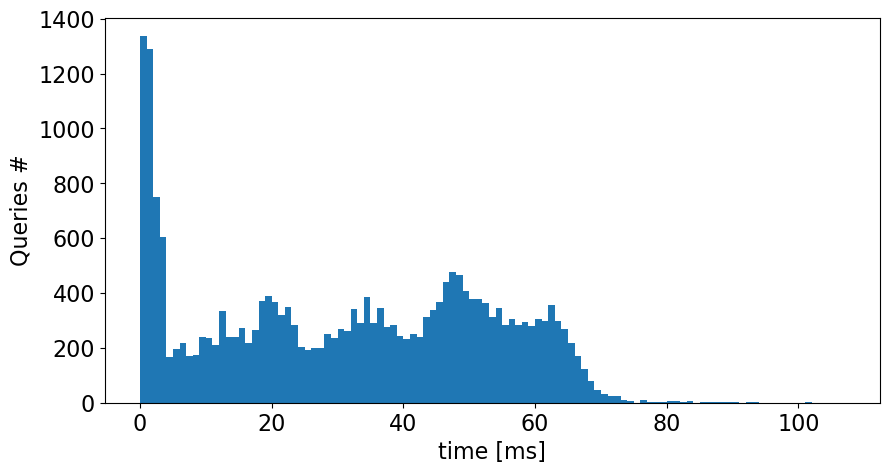

In [6]:
plots('benchmarking_ct_0_7.log', 'benchmark-fpsim2')


## benchmark-fpsim2-b256
**Total time**: 198094.684 ms

**Average time**: 8.773 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 17.643 |
| 90  | 15.118 |
| 75  | 13.345 |
| 50  | 9.674 |
| 25  | 3.921 |
    

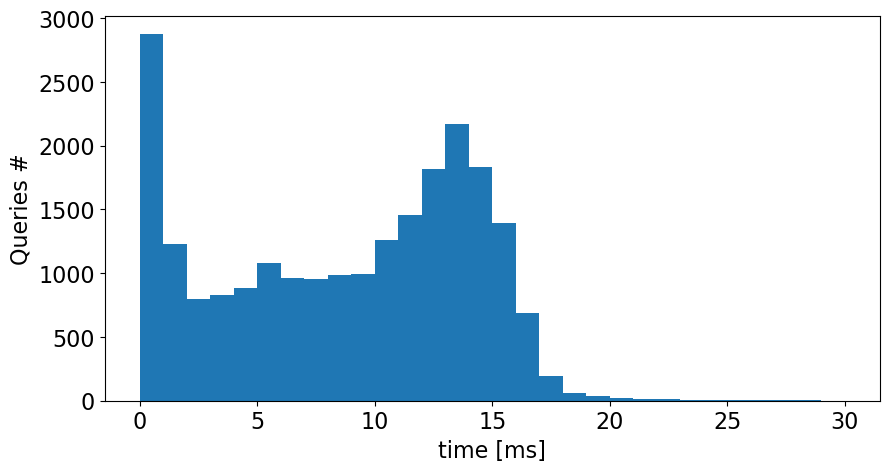

In [7]:
plots('benchmarking_b256_0_7.log', 'benchmark-fpsim2-b256')


## benchmark-fpsim2-b1024
**Total time**: 587770.913 ms

**Average time**: 26.029 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 57.406 |
| 90  | 47.298 |
| 75  | 40.470 |
| 50  | 27.344 |
| 25  | 11.006 |
    

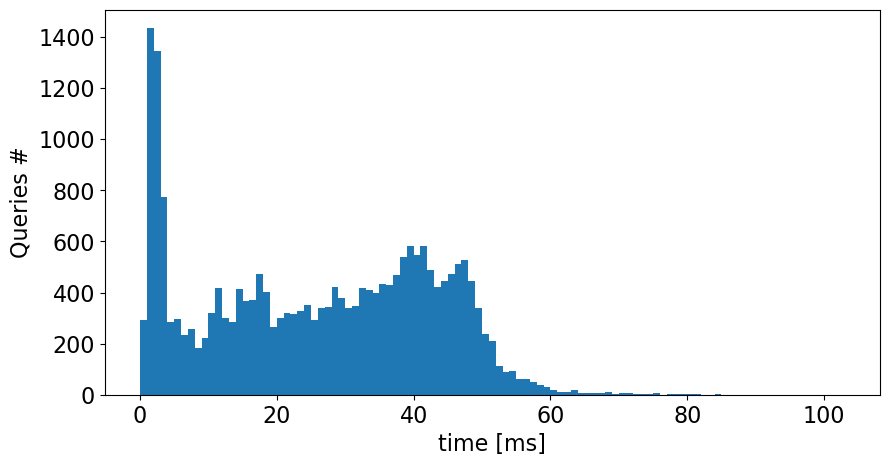

In [5]:
plots('benchmarking_b1024_0_7.log', 'benchmark-fpsim2-b1024')


## benchmark-fpsim2-b512
**Total time**: 283987.723 ms

**Average time**: 12.576 ms

| Queries resolved (percentile)  | Time (ms) |
| -------------------------------| -----------|
| 99  | 25.809 |
| 90  | 22.615 |
| 75  | 19.116 |
| 50  | 13.471 |
| 25  | 5.369 |
    

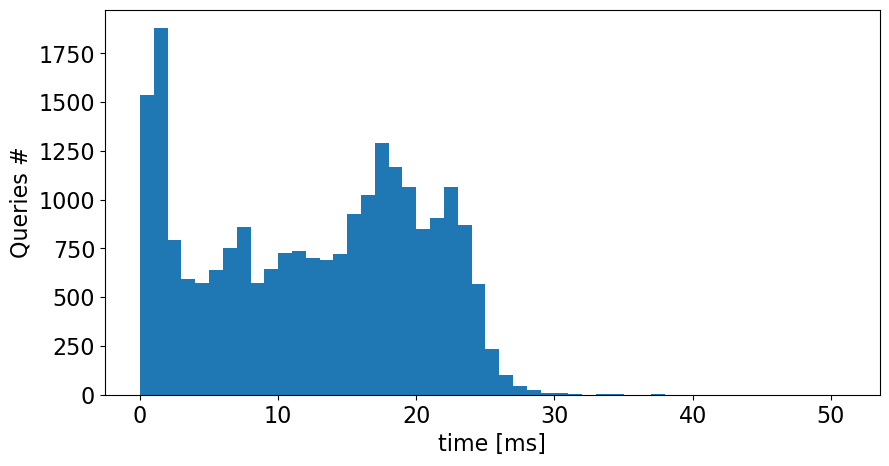

In [8]:
plots('benchmarking_b512_0_7.log', 'benchmark-fpsim2-b512')

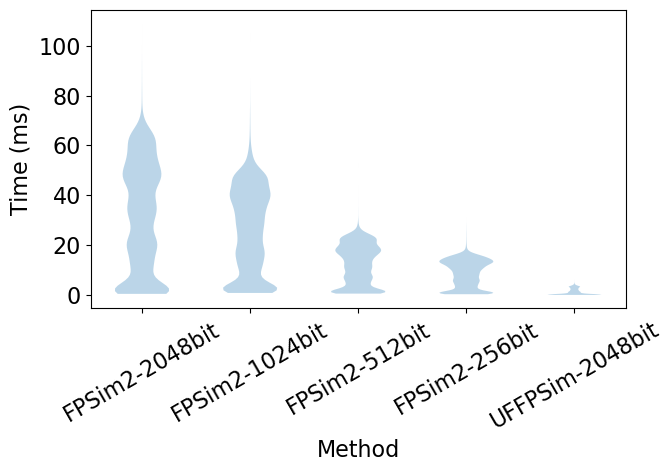

In [6]:
fpsim2_data_b2048 = read_file('benchmarking_ct_0_7.log')
fpsim2_data_b1024 = read_file('benchmarking_b1024_0_7.log')
fpsim2_data_b512 = read_file('benchmarking_b512_0_7.log')
fpsim2_data_b256 = read_file('benchmarking_b256_0_7.log')
uffpsim_data = read_file('../benchmark/benchmark.log')

fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_subplot(111)
ax1.violinplot([fpsim2_data_b2048, fpsim2_data_b1024, fpsim2_data_b512, fpsim2_data_b256, uffpsim_data], showextrema=False)
ax1.set_xlabel('Method')
ax1.set_xticks([1,2,3,4,5],["FPSim2-2048bit","FPSim2-1024bit", "FPSim2-512bit","FPSim2-256bit","UFFPSim-2048bit"])
#ax1.set_xticks([1,2,3],["2048bit","512bit","256bit"])
ax1.tick_params(axis='x', labelrotation=30)
#ax1.set_xlim(0, 90)
ax1.set_ylabel('Time (ms)')
fig.tight_layout()

fig.savefig(f'comparison.png', dpi=300)
plt.show()